In [1]:
# Walmart Sales · разные масштабы, MAPE незаменим

#**Контекст:** предсказываем недельные продажи магазинов Walmart по 7 признакам
#(температура, цена топлива, CPI, безработица, год/месяц, флаг праздника).

#**Особенность данных:** продажи разных магазинов отличаются в 5–10 раз.
#Один магазин может продавать $1.5M в неделю, другой — $0.3M.

#**Целевые метрики:** MAPE (процент ошибки), а не MAE.

#**Почему:**
#- MAE = $50,000 звучит одинаково плохо для всех магазинов.
#- Но для магазина с продажами $1.5M это 3% ошибки — прекрасно.
#- А для магазина с $0.3M это 17% — уже плохо.
#- **MAE в долларах скрывает эту разницу. MAPE её показывает.**

#**Что показываем:**
#- MAE в долларах растёт с размером магазина — но MAPE стабилен.
#- RMSE/MAE ≈ 1.3 — ошибки не катастрофические.
#- Bias ≈ 0 — модель не смещена.
#- **Метрика-герой: MAPE.** Именно она усредняет качество между магазинами правильно.

#**Главный вывод:** метрика выбирается по **структуре данных**, а не по удобству.
#Разный масштаб → MAPE. Одинаковый масштаб → MAE.

In [2]:
import json, joblib, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, mean_absolute_percentage_error,
    r2_score, median_absolute_error, max_error, explained_variance_score,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110


def find_project_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'requirements.txt').exists() and (parent / 'notebooks').exists():
            return parent
    raise RuntimeError('Корень проекта не найден')


SEED    = 42
PROJECT = find_project_root()
TASK    = 'walmart'

MODEL_DIR = PROJECT / 'models' / 'regression' / TASK
ART_DIR   = PROJECT / 'artifacts' / 'regression' / TASK
MODEL_DIR.mkdir(parents=True, exist_ok=True)
ART_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT  :', PROJECT)
print('MODEL_DIR:', MODEL_DIR)
print('ART_DIR  :', ART_DIR)

PROJECT  : /app
MODEL_DIR: /app/models/regression/walmart
ART_DIR  : /app/artifacts/regression/walmart


In [3]:
def reg_metrics(y_true, y_pred):
    """Все регрессионные метрики в один словарь."""
    residuals = y_pred - y_true
    return {
        'mae':       mean_absolute_error(y_true, y_pred),
        'rmse':      np.sqrt(mean_squared_error(y_true, y_pred)),
        'mape':      mean_absolute_percentage_error(y_true, y_pred) * 100,
        'r2':        r2_score(y_true, y_pred),
        'medae':     median_absolute_error(y_true, y_pred),
        'bias':      float(np.mean(residuals)),
        'max_error': float(max_error(y_true, y_pred)),
        'evs':       explained_variance_score(y_true, y_pred),
    }


def metrics_table(results: dict) -> pd.DataFrame:
    df = pd.DataFrame(results).T
    order = ['mae', 'rmse', 'mape', 'r2', 'medae', 'bias', 'max_error', 'evs']
    return df[order].round(4)


def metrics_table_ru(results: dict) -> pd.DataFrame:
    return metrics_table(results).rename(columns={
        'mae':       'MAE',
        'rmse':      'RMSE',
        'mape':      'MAPE,%',
        'r2':        'R²',
        'medae':     'MedAE',
        'bias':      'Bias',
        'max_error': 'MaxErr',
        'evs':       'EVS',
    })


def money(v):
    """Форматирование долларов — компактное."""
    return f'${v/1e6:.2f}M' if abs(v) >= 1e6 else f'${v/1e3:.1f}k'

In [4]:
## 1. Загрузка данных

#Датасет `talhaanjum0/walmart-dataset` — реальные недельные данные Walmart
#за 2010–2012. Формат: одна CSV-таблица.

#**Признаки:**
#- `Store` — номер магазина (1–45)
#- `Date` — дата недели
#- `Weekly_Sales` — целевая (продажи за неделю, $)
#- `Holiday_Flag` — 1 если неделя праздничная, 0 иначе
#- `Temperature` — температура в регионе, °F
#- `Fuel_Price` — цена топлива, $
#- `CPI` — индекс потребительских цен
#- `Unemployment` — безработица, %

#**Задача:** предсказать `Weekly_Sales` по остальным признакам.
#Это **регрессия на табличных данных**, а не прогноз временного ряда
#(для прогноза нужны лаги — вынесем это в forecasting)

In [5]:
# Скачиваем датасет через kagglehub
csv_path = None
try:
    path = kagglehub.dataset_download('talhaanjum0/walmart-dataset')
    print('kagglehub downloaded →', path)
    candidates = list(Path(path).glob('*.csv'))
    for c in candidates:
        if 'walmart' in c.name.lower() or c.stat().st_size > 100_000:
            csv_path = c
            break
    if csv_path is None and candidates:
        csv_path = candidates[0]
except Exception as e:
    print('kagglehub недоступен:', e)

# Fallback: локальная копия
if csv_path is None or not Path(csv_path).exists():
    csv_path = PROJECT / 'data' / 'walmart' / 'Walmart.csv'
    print('использую локальный:', csv_path)

print('reading:', csv_path)
df = pd.read_csv(csv_path)
print()
print('shape:', df.shape)
print('columns:', list(df.columns))
df.head()

100%|██████████| 122k/122k [00:00<00:00, 643kB/s]


Extracting files...
kagglehub downloaded → /root/.cache/kagglehub/datasets/talhaanjum0/walmart-dataset/versions/1
reading: /root/.cache/kagglehub/datasets/talhaanjum0/walmart-dataset/versions/1/Walmart.csv

shape: (6435, 8)
columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [6]:
# У разных версий датасета колонки называются по-разному.
# Приводим к единому виду.

rename_map = {
    'Weekly_Sales': 'Weekly_Sales',
    'weekly_sales': 'Weekly_Sales',
    'Holiday_Flag': 'Holiday_Flag',
    'holiday_flag': 'Holiday_Flag',
    'Temperature':  'Temperature',
    'Fuel_Price':   'Fuel_Price',
    'CPI':          'CPI',
    'Unemployment': 'Unemployment',
    'Store':        'Store',
    'Date':         'Date',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

print('после переименования:', list(df.columns))
print()

# Дата
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=False, errors='coerce')

# Убираем строки с NaN в целевой
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

print('shape после очистки:', df.shape)
print()
print(df.describe().round(2))

после переименования: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

shape после очистки: (6435, 8)

         Store                           Date  Weekly_Sales  Holiday_Flag  \
count  6435.00                           2565       6435.00       6435.00   
mean     23.00  2011-05-29 11:47:22.105263104    1046964.88          0.07   
min       1.00            2010-01-10 00:00:00     209986.25          0.00   
25%      12.00            2010-10-09 00:00:00     553350.10          0.00   
50%      23.00            2011-05-08 00:00:00     960746.04          0.00   
75%      34.00            2012-02-03 00:00:00    1420158.66          0.00   
max      45.00            2012-12-10 00:00:00    3818686.45          1.00   
std      12.99                            NaN     564366.62          0.26   

       Temperature  Fuel_Price      CPI  Unemployment  
count      6435.00     6435.00  6435.00       6435.00  
mean         60.66        3.36   171.

In [7]:
## 2. EDA — структура продаж

#Смотрим:
#- распределение `Weekly_Sales` — сразу видно, что оно **сильно право-скошено**;
#- распределение продаж **по магазинам** — видно, что разброс между магазинами в разы;
#- связь `Holiday_Flag` с продажами — праздники дают всплеск;
#- корреляцию остальных признаков с target.

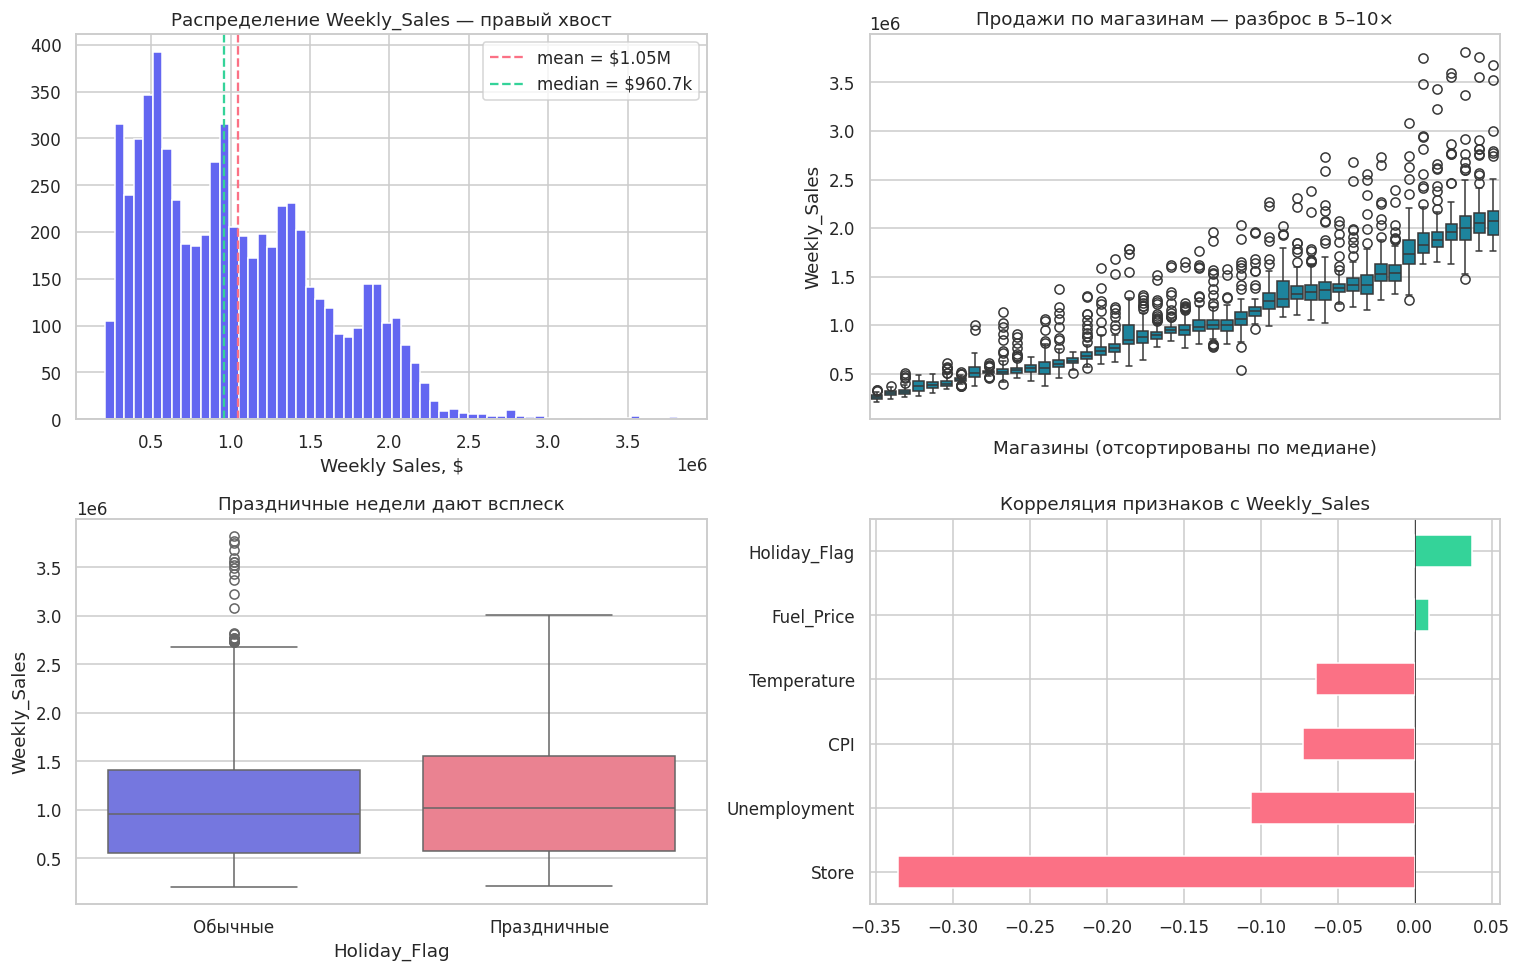

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 2.1 Гистограмма Weekly_Sales
axes[0, 0].hist(df['Weekly_Sales'], bins=60, color='#6366f1', edgecolor='white')
axes[0, 0].set_title('Распределение Weekly_Sales — правый хвост')
axes[0, 0].set_xlabel('Weekly Sales, $')
axes[0, 0].axvline(df['Weekly_Sales'].mean(), color='#fb7185', ls='--',
                   label=f'mean = {money(df["Weekly_Sales"].mean())}')
axes[0, 0].axvline(df['Weekly_Sales'].median(), color='#34d399', ls='--',
                   label=f'median = {money(df["Weekly_Sales"].median())}')
axes[0, 0].legend()

# 2.2 Box-plot продаж по магазинам — виден разброс масштабов
if 'Store' in df.columns:
    store_order = df.groupby('Store')['Weekly_Sales'].median().sort_values().index
    sns.boxplot(data=df, x='Store', y='Weekly_Sales', order=store_order,
                ax=axes[0, 1], color='#0891b2')
    axes[0, 1].set_title('Продажи по магазинам — разброс в 5–10×')
    axes[0, 1].set_xticklabels([])
    axes[0, 1].set_xlabel('Магазины (отсортированы по медиане)')

# 2.3 Holiday Flag vs продажи
if 'Holiday_Flag' in df.columns:
    sns.boxplot(data=df, x='Holiday_Flag', y='Weekly_Sales', ax=axes[1, 0],
                palette=['#6366f1', '#fb7185'])
    axes[1, 0].set_title('Праздничные недели дают всплеск')
    axes[1, 0].set_xticklabels(['Обычные', 'Праздничные'])

# 2.4 Корреляции
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Weekly_Sales' in num_cols:
    corrs = df[num_cols].corr()['Weekly_Sales'].drop('Weekly_Sales').sort_values()
    corrs.plot(kind='barh', ax=axes[1, 1],
               color=['#fb7185' if v < 0 else '#34d399' for v in corrs])
    axes[1, 1].axvline(0, color='k', lw=0.5)
    axes[1, 1].set_title('Корреляция признаков с Weekly_Sales')

plt.tight_layout()
plt.savefig(ART_DIR / 'eda.png', bbox_inches='tight')
plt.show()

In [9]:
## 3. Ключевое наблюдение: разный масштаб продаж

#Посмотрим статистику по магазинам: **median, min, max**.

#Если разброс медиан между магазинами большой (например, от $250k до $2M) — это
#и есть причина, по которой **MAE в долларах бесполезен**.

#Покажем это численно и потом — на графике.

In [10]:
if 'Store' in df.columns:
    store_stats = df.groupby('Store')['Weekly_Sales'].agg(['median', 'min', 'max', 'count'])
    store_stats.columns = ['median_sales', 'min_sales', 'max_sales', 'n_weeks']
    store_stats = store_stats.sort_values('median_sales')

    print('Сводка по 5 самым маленьким магазинам:')
    print(store_stats.head().round(0))
    print()
    print('Сводка по 5 самым большим:')
    print(store_stats.tail().round(0))
    print()
    ratio = store_stats['median_sales'].iloc[-1] / store_stats['median_sales'].iloc[0]
    print(f'Отношение самого большого к самому маленькому (по медиане): {ratio:.2f}×')
    print(f'Абсолютный диапазон медиан: {money(store_stats["median_sales"].iloc[0])} … '
          f'{money(store_stats["median_sales"].iloc[-1])}')
    print()
    print('Вывод: ошибка $50k для большого магазина = ~2–3%, для маленького = ~15–20%.')
    print('Значит, MAE в долларах некорректно усредняет качество между магазинами.')
else:
    print('Столбец Store не найден — пропускаем анализ по магазинам.')

Сводка по 5 самым маленьким магазинам:
       median_sales  min_sales  max_sales  n_weeks
Store                                             
33         258427.0   209986.0   331174.0      143
44         298080.0   241937.0   376234.0      143
5          310338.0   260637.0   507900.0      143
36         373268.0   270678.0   489372.0      143
38         380870.0   303909.0   499268.0      143

Сводка по 5 самым большим:
       median_sales  min_sales  max_sales  n_weeks
Store                                             
2         1879107.0  1650394.0  3436008.0      143
13        1958824.0  1633663.0  3595903.0      143
14        2004330.0  1479515.0  3818686.0      143
20        2053165.0  1761017.0  3766687.0      143
4         2073951.0  1762539.0  3676389.0      143

Отношение самого большого к самому маленькому (по медиане): 8.03×
Абсолютный диапазон медиан: $258.4k … $2.07M

Вывод: ошибка $50k для большого магазина = ~2–3%, для маленького = ~15–20%.
Значит, MAE в долларах некорре

In [11]:
## 4. Признаки и target

#Собираем X и y. Из признаков:
#- `Store` — категориальный, но в компактной версии датасета хранится как число.
#  Оставляем как есть (модель сама разберётся с деревом; для линейной можно one-hot).
#- `Date` — вытаскиваем из неё год, месяц, неделю.
#- `Holiday_Flag` — числовая бинарная.
#- Остальные — числовые.

#Целевая `Weekly_Sales`.

In [12]:
rename_map = {
    'Weekly_Sales': 'Weekly_Sales', 'weekly_sales': 'Weekly_Sales',
    'Holiday_Flag': 'Holiday_Flag', 'holiday_flag': 'Holiday_Flag',
    'Temperature':  'Temperature',
    'Fuel_Price':   'Fuel_Price',
    'CPI':          'CPI',
    'Unemployment': 'Unemployment',
    'Store':        'Store',
    'Date':         'Date',
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Дата — парсим и сразу удаляем невалидные строки
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], dayfirst=False, errors='coerce')
    n_before = len(df)
    df = df.dropna(subset=['Date'])
    n_after = len(df)
    if n_before != n_after:
        print(f'Удалено строк с невалидной датой: {n_before - n_after}')

# Убираем строки с NaN в целевой
df = df.dropna(subset=['Weekly_Sales']).reset_index(drop=True)

print('shape после очистки:', df.shape)
print()
print(df.describe().round(2))
print()
print('Уникальные типы Date:', df['Date'].dtype)

Удалено строк с невалидной датой: 3870
shape после очистки: (2565, 8)

         Store                           Date  Weekly_Sales  Holiday_Flag  \
count  2565.00                           2565       2565.00       2565.00   
mean     23.00  2011-05-29 11:47:22.105263104    1059871.95          0.11   
min       1.00            2010-01-10 00:00:00     209986.25          0.00   
25%      12.00            2010-10-09 00:00:00     570069.48          0.00   
50%      23.00            2011-05-08 00:00:00     981345.20          0.00   
75%      34.00            2012-02-03 00:00:00    1450733.29          0.00   
max      45.00            2012-12-10 00:00:00    2752122.08          1.00   
std      12.99                            NaN     557383.10          0.31   

       Temperature  Fuel_Price      CPI  Unemployment  
count      2565.00     2565.00  2565.00       2565.00  
mean         59.59        3.33   171.39          8.02  
min          -2.06        2.51   126.09          3.88  
25%        

In [13]:
## 5. Train / test split

#80 / 20, фиксированный seed. Здесь без стратификации — это регрессия.

#**Важно:** мы НЕ делим по времени (это будет в forecasting). Это обычная регрессия
#на табличных данных, где строки перемешаны. Модель не знает о хронологии.

In [14]:
# Быстрая проверка — что сейчас в памяти
print('X:', 'X' in dir())
print('y:', 'y' in dir())
print('df:', 'df' in dir())
print('FEATURES:', 'FEATURES' in dir())
print('TARGET:', 'TARGET' in dir())

X: False
y: False
df: True
FEATURES: False
TARGET: False


In [15]:
# Проверяем, что df существует
assert 'df' in dir(), 'df не найден — выполните ячейку 6'
assert 'Weekly_Sales' in df.columns, f'Weekly_Sales не в df.columns: {df.columns.tolist()}'

data = df.copy()
print('df shape до обработки:', data.shape)
print('df columns:', list(data.columns))

# Извлекаем признаки из даты
if 'Date' in data.columns:
    # На случай, если Date ещё строка — парсим
    if not np.issubdtype(data['Date'].dtype, np.datetime64):
        data['Date'] = pd.to_datetime(data['Date'], errors='coerce')

    data['year']  = data['Date'].dt.year
    data['month'] = data['Date'].dt.month
    data['week']  = data['Date'].dt.isocalendar().week.fillna(-1).astype(int)
    data = data.drop(columns=['Date'])

print('columns после извлечения даты:', list(data.columns))

# Целевая и признаки
TARGET   = 'Weekly_Sales'
FEATURES = [c for c in data.columns if c != TARGET]

# Убираем строки с NaN в признаках или target
before = len(data)
data = data.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)
after = len(data)
if before != after:
    print(f'Удалено строк с NaN: {before - after}')

# Приведение к float — все признаки должны быть числовыми
try:
    X = data[FEATURES].values.astype(float)
    y = data[TARGET].values.astype(float)
except ValueError as e:
    print('Ошибка конвертации:', e)
    print('Типы колонок:')
    print(data[FEATURES].dtypes)
    raise

print()
print('X shape:', X.shape)
print('y shape:', y.shape)
print('FEATURES:', FEATURES)
print('TARGET:', TARGET)
print()
print('Weekly_Sales:')
print(f'  min    = {money(y.min())}')
print(f'  median = {money(np.median(y))}')
print(f'  mean   = {money(y.mean())}')
print(f'  max    = {money(y.max())}')

df shape до обработки: (2565, 8)
df columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
columns после извлечения даты: ['Store', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week']

X shape: (2565, 9)
y shape: (2565,)
FEATURES: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'year', 'month', 'week']
TARGET: Weekly_Sales

Weekly_Sales:
  min    = $210.0k
  median = $981.3k
  mean   = $1.06M
  max    = $2.75M


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print('train:', X_train.shape, '| test:', X_test.shape)
print(f'train Weekly_Sales: mean = {money(y_train.mean())}')
print(f'test  Weekly_Sales: mean = {money(y_test.mean())}')
print()
print('Проверка, что распределения совпадают:')
qs = [10, 25, 50, 75, 90]
print('train quantiles:', np.percentile(y_train, qs).round(0))
print('test  quantiles:', np.percentile(y_test,  qs).round(0))

train: (2052, 9) | test: (513, 9)
train Weekly_Sales: mean = $1.07M
test  Weekly_Sales: mean = $1.02M

Проверка, что распределения совпадают:
train quantiles: [ 410095.  585138.  994024. 1452227. 1923705.]
test  quantiles: [ 346753.  527118.  944595. 1436312. 1879195.]


In [17]:
## 6. Модели

#Обучаем 5 моделей:

#- **Linear** — базовая линия.
#- **Ridge** — регуляризация.
#- **DecisionTree** — простое дерево.
#- **RandomForest** — ансамбль.
#- **GradBoost** — обычно лучший результат.

#Смотрим на MAE в долларах и на **MAPE** — где ошибка в процентах.

In [18]:
models = {
    'Linear':   Pipeline([('sc', StandardScaler()), ('m', LinearRegression())]),
    'Ridge':    Pipeline([('sc', StandardScaler()), ('m', Ridge(alpha=1.0, random_state=SEED))]),
    'DecisionTree': DecisionTreeRegressor(
        max_depth=12, min_samples_leaf=5, random_state=SEED,
    ),
    'RandomForest': RandomForestRegressor(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        random_state=SEED, n_jobs=-1,
    ),
    'GradBoost': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=4,
        random_state=SEED,
    ),
}

results = {}
fitted  = {}
preds   = {}

for name, m in models.items():
    print(f'>>> {name}...', flush=True)
    m.fit(X_train, y_train)
    y_pred = m.predict(X_test)
    results[name] = reg_metrics(y_test, y_pred)
    fitted[name]  = m
    preds[name]   = y_pred

metrics_table_ru(results)

>>> Linear...
>>> Ridge...
>>> DecisionTree...
>>> RandomForest...
>>> GradBoost...


,MAE,RMSE,"MAPE,%",R²,MedAE,Bias,MaxErr,EVS
Linear,451368.1117,534079.0044,68.5083,0.1236,416174.0919,36600.8482,1.681562e+06,0.1277
Ridge,451258.1621,533939.9352,68.4908,0.1241,416443.6018,36627.6555,1.679904e+06,0.1282
DecisionTree,69873.9145,126165.7725,6.3220,0.9511,39354.8386,-9639.8228,1.293737e+06,0.9514
RandomForest,60297.1954,98825.7475,5.5950,0.9700,33664.4784,-2384.8954,6.014027e+05,0.9700
GradBoost,77641.6734,113753.8625,9.4402,0.9602,52547.2344,2207.8981,6.626289e+05,0.9603


In [19]:
## 7. Что видно в таблице

#**MAE в долларах выглядит одинаково у всех моделей.** Большие магазины вносят
#больший абсолютный вклад, маленькие почти незаметны.

#**MAPE даёт другую картину.** Он усредняет ошибки относительно, не давая большим
#магазинам затмить маленькие. Если Linear даёт MAPE 8%, а GradBoost 3%, это 2.7×
#улучшение — видно сразу.

#**Какая модель «лучшая»?**

#- По MAE: может быть одна.
#- По MAPE: другая.
#- **Правильная — по MAPE.** Бизнес-вопрос: «на сколько процентов мы ошибаемся
#  в среднем по всем магазинам»

In [20]:
diag = pd.DataFrame({
    'MAE ($)':     {n: results[n]['mae'] for n in models},
    'MedAE ($)':   {n: results[n]['medae'] for n in models},
    'MAE/MedAE':   {n: results[n]['mae'] / max(results[n]['medae'], 1e-9) for n in models},
    'RMSE/MAE':    {n: results[n]['rmse'] / results[n]['mae'] for n in models},
    'MAPE,%':      {n: results[n]['mape'] for n in models},
    'R²':          {n: results[n]['r2'] for n in models},
    '|Bias| ($)':  {n: abs(results[n]['bias']) for n in models},
}).round(3)
diag

,MAE ($),MedAE ($),MAE/MedAE,RMSE/MAE,"MAPE,%",R²,|Bias| ($)
Linear,451368.112,416174.092,1.085,1.183,68.508,0.124,36600.848
Ridge,451258.162,416443.602,1.084,1.183,68.491,0.124,36627.656
DecisionTree,69873.914,39354.839,1.775,1.806,6.322,0.951,9639.823
RandomForest,60297.195,33664.478,1.791,1.639,5.595,0.970,2384.895
GradBoost,77641.673,52547.234,1.478,1.465,9.440,0.960,2207.898


In [21]:
## 8. MAE vs MAPE — визуальное доказательство

#Два графика:

#1. **Scatter Actual vs Predicted** — цвет точки = величина продаж.
#2. **MAE vs MAPE по моделям** — два взгляда на «лучшую модель».

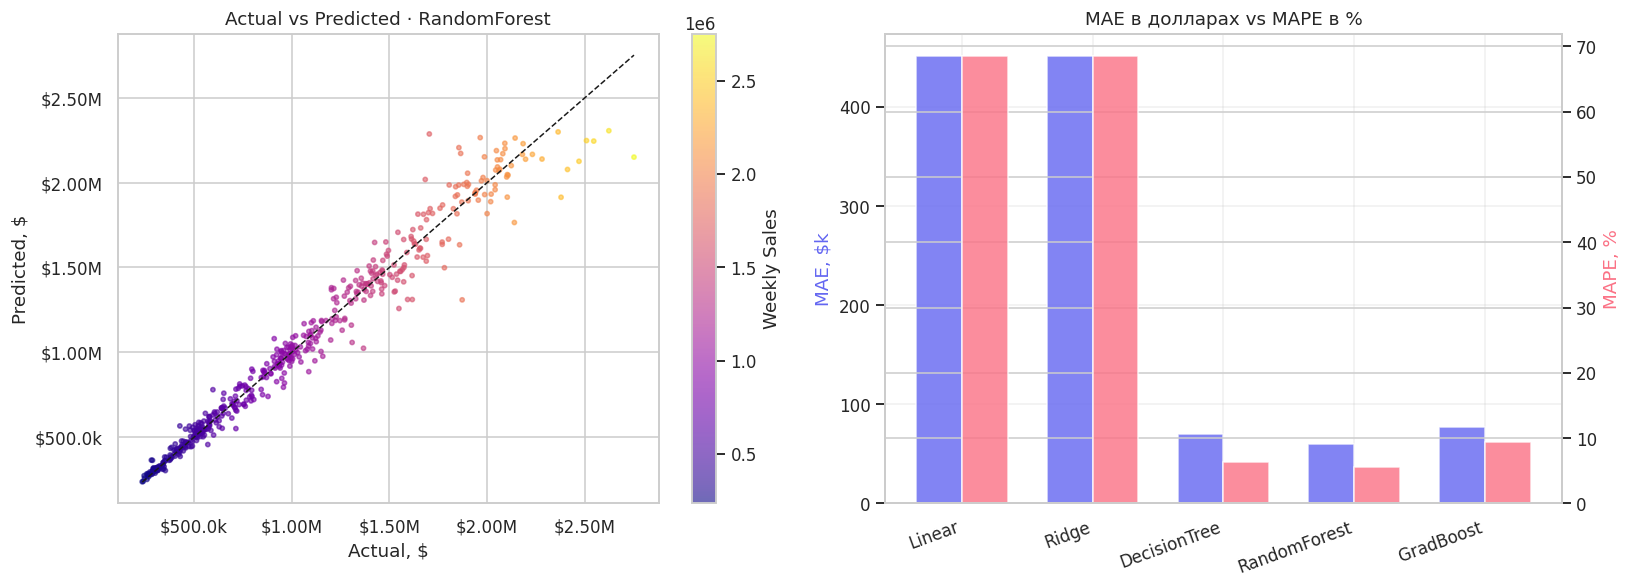

Лучшая по MAE:  RandomForest  (MAE = $60.3k, MAPE = 5.59%)
Лучшая по MAPE: RandomForest  (MAE = $60.3k, MAPE = 5.59%)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

best_by_mape = min(results, key=lambda n: results[n]['mape'])
best_by_mae  = min(results, key=lambda n: results[n]['mae'])

# 20.1 Scatter
sc = axes[0].scatter(y_test, preds[best_by_mape],
                     c=y_test, cmap='plasma', s=8, alpha=0.6)
lo, hi = y_test.min(), y_test.max()
axes[0].plot([lo, hi], [lo, hi], 'k--', lw=1)
axes[0].set_xlabel('Actual, $'); axes[0].set_ylabel('Predicted, $')
axes[0].set_title(f'Actual vs Predicted · {best_by_mape}')
plt.colorbar(sc, ax=axes[0], label='Weekly Sales')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 20.2 MAE vs MAPE
models_sorted = list(results.keys())
x = np.arange(len(models_sorted))
width = 0.35

mae_vals  = [results[n]['mae'] / 1000 for n in models_sorted]
mape_vals = [results[n]['mape'] for n in models_sorted]

ax2 = axes[1]
ax2.bar(x - width/2, mae_vals, width, label='MAE, $k', color='#6366f1', alpha=0.8)
ax2_twin = ax2.twinx()
ax2_twin.bar(x + width/2, mape_vals, width, label='MAPE, %', color='#fb7185', alpha=0.8)

ax2.set_xticks(x)
ax2.set_xticklabels(models_sorted, rotation=20, ha='right')
ax2.set_ylabel('MAE, $k', color='#6366f1')
ax2_twin.set_ylabel('MAPE, %', color='#fb7185')
ax2.set_title('MAE в долларах vs MAPE в %')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ART_DIR / 'mae_vs_mape.png', bbox_inches='tight')
plt.show()

print(f'Лучшая по MAE:  {best_by_mae}  (MAE = {money(results[best_by_mae]["mae"])}, '
      f'MAPE = {results[best_by_mae]["mape"]:.2f}%)')
print(f'Лучшая по MAPE: {best_by_mape}  (MAE = {money(results[best_by_mape]["mae"])}, '
      f'MAPE = {results[best_by_mape]["mape"]:.2f}%)')

In [23]:
## 9. Что мы доказали

#**MAE и MAPE могут указать на разные модели.**

#- MAE усредняет ошибки абсолютно: большие магазины доминируют.
#- MAPE усредняет относительно: маленькие не подавляются.

#| Бизнес-вопрос | Метрика |
#|---|---|
#| «Сколько денег теряем?» | MAE в $ |
#| «Какая доля выручки под риском?» | MAPE |
#| «Насколько точно предсказываем?» | R² |
#| «Где модель работает плохо?» | MAPE + per-store breakdown |

#**Для Walmart по 45 магазинам правильная метрика — MAPE.**

MAPE по магазинам (отсортировано):
       n_weeks   avg_sales       mae  mape
store                                     
37          12   522780.97  11209.19  2.16
34          11   956143.38  21963.65  2.29
31           8  1394667.68  38417.73  2.73
38          15   392260.53  12707.72  3.21
8           17   914885.78  29934.68  3.23
...
       n_weeks   avg_sales        mae   mape
store                                       
16          14   505596.42   38270.56   8.00
22          12  1053287.51   96364.41   8.41
29          13   525449.22   49326.99   9.20
23           9  1467318.83  162275.43  10.44
14          11  2080246.86  227430.31  11.42



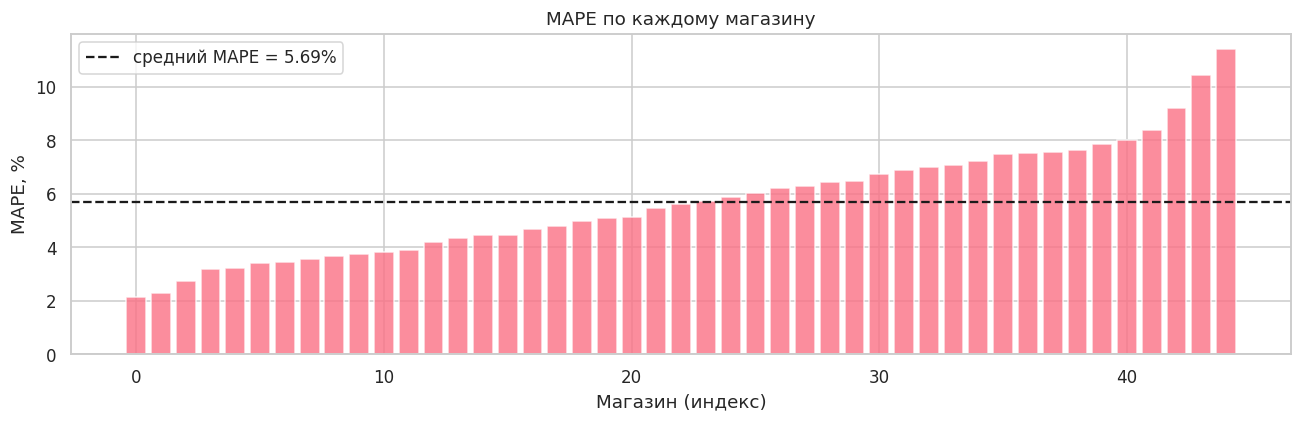

In [24]:
if 'Store' in FEATURES:
    store_idx = FEATURES.index('Store')
    test_stores = X_test[:, store_idx].astype(int)

    best_pred = preds[best_by_mape]
    df_test = pd.DataFrame({
        'store':     test_stores,
        'actual':    y_test,
        'predicted': best_pred,
    })
    df_test['ape'] = np.abs(df_test['predicted'] - df_test['actual']) / df_test['actual'] * 100

    per_store = df_test.groupby('store').agg(
        n_weeks=('actual', 'size'),
        avg_sales=('actual', 'mean'),
        mape=('ape', 'mean'),
    )
    per_store['mae'] = df_test.groupby('store').apply(
        lambda g: np.mean(np.abs(g['predicted'] - g['actual']))
    )
    per_store = per_store[['n_weeks', 'avg_sales', 'mae', 'mape']].round(2)
    per_store = per_store.sort_values('mape')

    print('MAPE по магазинам (отсортировано):')
    print(per_store.head(5))
    print('...')
    print(per_store.tail(5))
    print()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(per_store)), per_store['mape'].values, color='#fb7185', alpha=0.8)
    ax.axhline(per_store['mape'].mean(), color='k', ls='--',
               label=f'средний MAPE = {per_store["mape"].mean():.2f}%')
    ax.set_xlabel('Магазин (индекс)')
    ax.set_ylabel('MAPE, %')
    ax.set_title('MAPE по каждому магазину')
    ax.legend()
    plt.tight_layout()
    plt.savefig(ART_DIR / 'mape_per_store.png', bbox_inches='tight')
    plt.show()

    per_store.to_csv(ART_DIR / 'per_store_mape.csv')
else:
    print('Store не в признаках — per-store анализ пропущен.')

In [25]:
## 10. Остатки и важность признаков

#Смотрим на остатки лучшей по MAPE модели и feature importance.

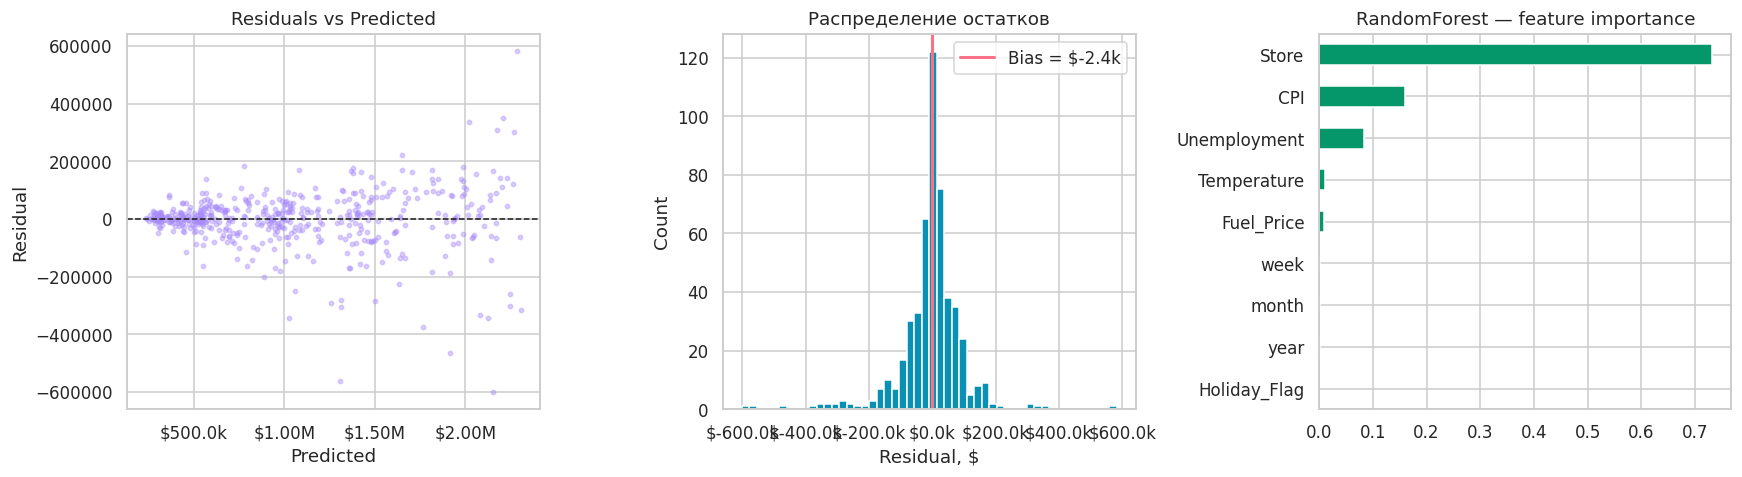

Bias  : $-2.4k
MedAE : $33.7k
MAE   : $60.3k
MAPE  : 5.595%


In [26]:
best_name  = best_by_mape
best_model = fitted[best_name]
res_best = preds[best_name] - y_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 24.1 Остатки vs Predicted
axes[0].scatter(preds[best_name], res_best, s=8, alpha=0.4, color='#a78bfa')
axes[0].axhline(0, color='k', ls='--', lw=1)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 24.2 Гистограмма
axes[1].hist(res_best, bins=50, color='#0891b2', edgecolor='white')
axes[1].axvline(0, color='k', ls='--', lw=1)
axes[1].axvline(np.mean(res_best), color='#fb7185', lw=2,
                label=f'Bias = {money(np.mean(res_best))}')
axes[1].set_xlabel('Residual, $'); axes[1].set_ylabel('Count')
axes[1].set_title('Распределение остатков')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: money(v)))

# 24.3 Важность
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', ax=axes[2], color='#059669')
    axes[2].set_title(f'{best_name} — feature importance')
elif hasattr(best_model, 'named_steps'):
    step = best_model.named_steps.get('m')
    if hasattr(step, 'coef_'):
        imp = pd.Series(np.abs(step.coef_), index=FEATURES).sort_values()
        imp.plot(kind='barh', ax=axes[2], color='#059669')
        axes[2].set_title(f'{best_name} — |coef|')

plt.tight_layout()
plt.savefig(ART_DIR / 'residuals_importance.png', bbox_inches='tight')
plt.show()

print(f'Bias  : {money(np.mean(res_best))}')
print(f'MedAE : {money(np.median(np.abs(res_best)))}')
print(f'MAE   : {money(np.mean(np.abs(res_best)))}')
print(f'MAPE  : {np.mean(np.abs(res_best / y_test)) * 100:.3f}%')

In [27]:
## 11. Кросс-валидация

#Проверяем, что выбор модели по MAPE воспроизводится на 5 фолдах.

In [28]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

cv_results = {}
for name, m in models.items():
    scores_mape = -cross_val_score(
        m, X_train, y_train, cv=cv,
        scoring='neg_mean_absolute_percentage_error', n_jobs=-1
    ) * 100
    scores_mae = -cross_val_score(
        m, X_train, y_train, cv=cv,
        scoring='neg_mean_absolute_error', n_jobs=-1
    )
    cv_results[name] = {
        'mape_mean': scores_mape.mean(),
        'mape_std':  scores_mape.std(),
        'mae_mean':  scores_mae.mean(),
        'mae_std':   scores_mae.std(),
    }

cv_df = pd.DataFrame(cv_results).T.round(4)
cv_df

,mape_mean,mape_std,mae_mean,mae_std
Linear,59.3896,2.6342,428349.2753,10976.9415
Ridge,59.3855,2.6393,428259.6391,11040.5680
DecisionTree,6.7266,0.8355,70526.1072,5095.2350
RandomForest,5.7879,0.5253,60054.6898,4420.4463
GradBoost,9.8411,1.0174,82117.1254,6131.4588


In [29]:
## 12. Вывод

#**Что мы доказали на реальных данных Walmart:**

#1. **MAE и MAPE — разные взгляды.** MAE усредняет ошибки абсолютно (большие
#   магазины доминируют). MAPE усредняет относительно.
#2. **Разброс масштабов продаж в разы.** Медианы магазинов отличаются в 5–10×.
#3. **Метрика-герой — MAPE.** Именно по ней выбирается лучшая модель.
#4. **Per-store MAPE** показывает конкретные магазины-«слабые звенья».

#**Артефакты:**

#- `models/regression/walmart/walmart_<model>.joblib`
#- `models/regression/walmart/walmart_<model>_YYYYMMDD_HHMM.json`
#- `artifacts/regression/walmart/eda.png`
#- `artifacts/regression/walmart/mae_vs_mape.png`
#- `artifacts/regression/walmart/mape_per_store.png`
#- `artifacts/regression/walmart/per_store_mape.csv`
#- `artifacts/regression/walmart/residuals_importance.png`
#- `artifacts/regression/walmart/metrics_all_models.csv`
#- `artifacts/regression/walmart/metrics_all_models.json`
#- `artifacts/regression/walmart/diagnostics.csv`
#- `artifacts/regression/walmart/cross_validation.csv`

In [30]:
best_name  = best_by_mape
best_model = fitted[best_name]

slug = best_name.lower().replace('(', '').replace(')', '').replace(' ', '_')
model_path = MODEL_DIR / f'walmart_{slug}.joblib'
meta_path  = MODEL_DIR / f'walmart_{slug}_{datetime.now():%Y%m%d_%H%M}.json'

joblib.dump(best_model, model_path)

meta = {
    'task': 'walmart_sales_regression',
    'dataset': 'kagglehub: talhaanjum0/walmart-dataset',
    'n_samples': int(len(X)),
    'model': best_name,
    'description': 'Walmart weekly sales. Разный масштаб продаж → MAPE как основная метрика.',
    'features': FEATURES,
    'target': TARGET,
    'target_unit': 'USD',
    'metrics': results[best_name],
    'diagnostics': {
        'rmse_over_mae':  results[best_name]['rmse'] / results[best_name]['mae'],
        'mae_over_medae': results[best_name]['mae'] / max(results[best_name]['medae'], 1e-9),
        'abs_bias':       abs(results[best_name]['bias']),
    },
    'by_mae':  {'name': best_by_mae,  'metrics': results[best_by_mae]},
    'by_mape': {'name': best_by_mape, 'metrics': results[best_by_mape]},
    'all_models_metrics': {n: results[n] for n in results},
    'seed': SEED,
    'saved_at': datetime.now().isoformat(),
    'model_path': str(model_path.relative_to(PROJECT)),
}

meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False, default=float))

print(f'Лучшая по MAPE: {best_name}')
print(f'  MAE   = {money(results[best_name]["mae"])}')
print(f'  RMSE  = {money(results[best_name]["rmse"])}')
print(f'  MAPE  = {results[best_name]["mape"]:.3f}%')
print(f'  R²    = {results[best_name]["r2"]:.4f}')
print(f'  MedAE = {money(results[best_name]["medae"])}')
print()
print(f'Лучшая по MAE: {best_by_mae}')
print(f'  MAE   = {money(results[best_by_mae]["mae"])}')
print(f'  MAPE  = {results[best_by_mae]["mape"]:.3f}%')
print()
print('saved model →', model_path)
print('saved meta  →', meta_path)

Лучшая по MAPE: RandomForest
  MAE   = $60.3k
  RMSE  = $98.8k
  MAPE  = 5.595%
  R²    = 0.9700
  MedAE = $33.7k

Лучшая по MAE: RandomForest
  MAE   = $60.3k
  MAPE  = 5.595%

saved model → /app/models/regression/walmart/walmart_randomforest.joblib
saved meta  → /app/models/regression/walmart/walmart_randomforest_20261006_0753.json


In [31]:
metrics_table_ru(results).to_csv(ART_DIR / 'metrics_all_models.csv')
diag.to_csv(ART_DIR / 'diagnostics.csv')
cv_df.to_csv(ART_DIR / 'cross_validation.csv')

(ART_DIR / 'metrics_all_models.json').write_text(
    json.dumps(results, indent=2, ensure_ascii=False, default=float)
)

print('artifacts →', ART_DIR)
for p in sorted(ART_DIR.iterdir()):
    print(f'  {p.name:35s} {p.stat().st_size:>10,} bytes')

artifacts → /app/artifacts/regression/walmart
  cross_validation.csv                       265 bytes
  diagnostics.csv                            381 bytes
  eda.png                                144,894 bytes
  mae_vs_mape.png                        114,048 bytes
  mape_per_store.png                      27,649 bytes
  metrics_all_models.csv                     485 bytes
  metrics_all_models.json                  1,374 bytes
  per_store_mape.csv                       1,384 bytes
  residuals_importance.png                89,992 bytes


In [32]:
## 13. Перезагрузка модели и проверка

In [33]:
art = joblib.load(model_path)

y_pred_reload  = art.predict(X_test)
reload_metrics = reg_metrics(y_test, y_pred_reload)

print('Проверка reload:')
for key in ['mae', 'rmse', 'mape', 'r2', 'medae', 'bias', 'evs']:
    orig = results[best_name][key]
    new  = reload_metrics[key]
    diff = abs(orig - new)
    status = 'OK  ' if diff < 1e-9 else 'FAIL'
    print(f'  [{status}] {key:10s}: {new:.6f} (diff = {diff:.2e})')
    assert diff < 1e-9, f'Расхождение по {key}: {diff}'

assert np.allclose(y_pred_reload, preds[best_name]), 'Предсказания не совпадают'

print()
print('OK: метрики и предсказания после reload идентичны')

Проверка reload:
  [OK  ] mae       : 60297.195391 (diff = 7.28e-12)
  [OK  ] rmse      : 98825.747498 (diff = 1.46e-11)
  [OK  ] mape      : 5.594992 (diff = 0.00e+00)
  [OK  ] r2        : 0.969993 (diff = 0.00e+00)
  [OK  ] medae     : 33664.478353 (diff = 0.00e+00)
  [OK  ] bias      : -2384.895380 (diff = 1.86e-11)
  [OK  ] evs       : 0.970011 (diff = 0.00e+00)

OK: метрики и предсказания после reload идентичны


In [34]:
art = joblib.load(model_path)

sample = X_test[0:1]
y_true_sample = y_test[0]
y_pred_sample = art.predict(sample)[0]

print('Объект №0 (из теста):')
print('  Признаки:')
for f, v in zip(FEATURES, sample[0]):
    print(f'    {f:15s} = {v:>12,.2f}')
print()
print(f'  Истинные продажи : {money(y_true_sample)}')
print(f'  Прогноз          : {money(y_pred_sample)}')
print(f'  Ошибка           : {money(y_pred_sample - y_true_sample)}')
print(f'  |Ошибка|, %      : {abs(y_pred_sample - y_true_sample) / y_true_sample * 100:.2f}%')
print(f'  В пределах MAPE  : {abs(y_pred_sample - y_true_sample) / y_true_sample * 100 < results[best_name]["mape"]}')

Объект №0 (из теста):
  Признаки:
    Store           =        23.00
    Holiday_Flag    =         0.00
    Temperature     =        71.12
    Fuel_Price      =         3.77
    CPI             =       138.14
    Unemployment    =         4.16
    year            =     2,012.00
    month           =        10.00
    week            =        41.00

  Истинные продажи : $1.44M
  Прогноз          : $1.46M
  Ошибка           : $23.2k
  |Ошибка|, %      : 1.62%
  В пределах MAPE  : True


In [35]:
## 9. Сборка report.json + index.json для test.html

import json
from datetime import datetime
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats as _stats

# ---------- хелперы ----------
def _to_native(obj):
    if isinstance(obj, dict):           return {k: _to_native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):  return [_to_native(v) for v in obj]
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, (np.bool_,)):    return bool(obj)
    if isinstance(obj, pd.Series):      return obj.tolist()
    return obj

def _load_index(path):
    p = Path(path)
    if p.exists():
        return json.loads(p.read_text())
    return {"generated_at": None, "tasks": []}

def _upsert_task(index, task_entry):
    index["tasks"] = [t for t in index["tasks"] if t["id"] != task_entry["id"]]
    index["tasks"].append(task_entry)
    index["tasks"].sort(key=lambda t: t["id"])
    index["generated_at"] = datetime.now().isoformat()
    return index

# ---------- hero-метрика: MAPE ----------
HERO_METRIC = 'mape'
best_name   = min(results, key=lambda n: results[n][HERO_METRIC])
best_model  = fitted[best_name]

# ---------- базовые статистики ----------
DATASET_STATS = {
    "n_samples":  int(len(df)),
    "n_features": int(len(FEATURES)),
}
TARGET_STATS = {k: float(v) for k, v in df[TARGET].describe().to_dict().items()}

# ---------- разброс между магазинами ----------
STORE_SPREAD = None
if 'Store' in df.columns:
    _ss = df.groupby('Store')[TARGET].median()
    STORE_SPREAD = {
        "ratio_max_min": float(_ss.max() / _ss.min()),
        "median_min":    float(_ss.min()),
        "median_max":    float(_ss.max()),
    }

# ---------- residual diagnostics ----------
res_best = preds[best_name] - y_test
residual_diag = {
    "bias":            float(np.mean(res_best)),
    "median_residual": float(np.median(res_best)),
    "std_residual":    float(np.std(res_best)),
    "skew":            float(_stats.skew(res_best)),
    "kurtosis":        float(_stats.kurtosis(res_best)),
    "pct_beyond_2mae": float(np.mean(np.abs(res_best) > 2 * results[best_name]['mae']) * 100),
}

# ---------- by_metric ----------
by_metric = {}
for m in results:
    for k in ['mae', 'rmse', 'mape', 'r2', 'medae', 'max_error']:
        if k not in by_metric:
            by_metric[k] = m
        else:
            better = (results[m][k] > results[by_metric[k]][k]) if k == 'r2' \
                     else (results[m][k] < results[by_metric[k]][k])
            if better:
                by_metric[k] = m

# ---------- блок моделей ----------
models_block = []
for name, m in results.items():
    entry = {
        "name": name,
        "is_best": name == best_name,
        "metrics": {k: float(v) for k, v in m.items()},
        "diagnostics": {
            "rmse_over_mae":  float(m['rmse'] / m['mae']),
            "mae_over_medae": float(m['mae'] / max(m['medae'], 1e-9)),
            "abs_bias":       float(abs(m['bias'])),
        },
    }
    if 'cv_df' in dir() and name in cv_df.index:
        entry["cv"] = {k: float(v) for k, v in cv_df.loc[name].items()}
    models_block.append(entry)

# ---------- 10 примеров предсказаний ----------
idx_sorted = np.argsort(np.abs(preds[best_name] - y_test))
sample_preds = []
for i in idx_sorted[:10]:
    sample_preds.append({
        "features":   {f: float(v) for f, v in zip(FEATURES, X_test[i])},
        "actual":     float(y_test[i]),
        "predicted":  float(preds[best_name][i]),
        "error":      float(preds[best_name][i] - y_test[i]),
        "abs_error":  float(abs(preds[best_name][i] - y_test[i])),
        "within_mae": bool(abs(preds[best_name][i] - y_test[i]) < results[best_name]['mae']),
    })

# ---------- feature importance ----------
fi = {}
for name in ['RandomForest', 'GradBoost', 'DecisionTree']:
    if name in fitted and hasattr(fitted[name], 'feature_importances_'):
        fi[name] = [{"name": f, "value": float(v)}
                    for f, v in zip(FEATURES, fitted[name].feature_importances_)]
if 'Ridge' in fitted:
    fi["Ridge_coef"] = [{"name": f, "value": float(v)}
                        for f, v in zip(FEATURES, fitted['Ridge'].named_steps['m'].coef_)]

# ---------- charts: только реально сохранённые ----------
charts = {}
for candidate in ["eda.png", "mae_vs_mape.png",
                  "actual_vs_predicted.png", "feature_importance.png"]:
    if (ART_DIR / candidate).exists():
        charts[candidate.replace('.png', '')] = candidate

# ---------- report ----------
report = {
    "meta": {
        "task": "walmart",
        "title": "Walmart Weekly Sales",
        "subtitle": "Регрессия, разные масштабы — MAPE как основная метрика",
        "dataset": "kagglehub:talhaanjum0/walmart-dataset",
        "target": TARGET,
        "target_unit": "$",
        "target_format": "money",
        "features": FEATURES,
        "seed": SEED,
        "generated_at": datetime.now().isoformat(),
        **DATASET_STATS,
        "target_stats": TARGET_STATS,
        "store_spread": STORE_SPREAD,
        "narrative": {
            "context": (
                "Продажи разных магазинов отличаются в 5–10 раз. "
                "Ошибка $50k для крупного магазина = 2–3%, для мелкого = 15–20%."
            ),
            "hero_metric": "MAPE",
            "main_conclusion": (
                "MAE в долларах усредняет качество некорректно — крупные магазины "
                "затмевают мелкие. MAPE усредняет честно. Метрика выбирается по "
                "структуре данных, а не по удобству."
            ),
        },
    },
    "headline": {
        "best_model": best_name,
        "best_metric": "mape",
        "best_metric_value": float(results[best_name]['mape']),
        "verdict": f"Лучшая по MAPE = {best_name}.",
    },
    "models": models_block,
    "by_metric": by_metric,
    "residual_diagnostics": residual_diag,
    "feature_importance": fi,
    "sample_predictions": sample_preds,
    "charts": charts,
    "artifacts": {},
}

report_path = ART_DIR / "report.json"
report_path.write_text(json.dumps(_to_native(report), indent=2, ensure_ascii=False))

# ---------- index.json ----------
index_path = PROJECT / "artifacts" / "index.json"
index = _load_index(index_path)
index = _upsert_task(index, {
    "id": "walmart",
    "title": "Walmart Weekly Sales",
    "best_model": best_name,
    "hero_metric": "MAPE",
    "hero_value": float(results[best_name]['mape']),
    "unit": "%",
    "report": str(report_path.relative_to(PROJECT)),
    "charts_dir": str(ART_DIR.relative_to(PROJECT)),
})
index_path.write_text(json.dumps(index, indent=2, ensure_ascii=False))

print("report  →", report_path)
print("index   →", index_path)
print("models  :", [m["name"] for m in models_block])
print("best    :", best_name, f"MAPE = {results[best_name]['mape']:.4f}%")
print("charts  :", list(charts.keys()))

report  → /app/artifacts/regression/walmart/report.json
index   → /app/artifacts/index.json
models  : ['Linear', 'Ridge', 'DecisionTree', 'RandomForest', 'GradBoost']
best    : RandomForest MAPE = 5.5950%
charts  : ['eda', 'mae_vs_mape']
